# 第一阶段 · Notebook 2：Qiskit入门实践

> **配合学习**：IBM Quantum Learning — *Basics of Quantum Information*  
> **前置完成**：`01_量子计算基础与概念映射.ipynb`

---

## 本节目标
1. 掌握 Qiskit 1.x 的核心 API（QuantumCircuit、Primitives）
2. 实现 Bell 态制备（量子纠缠）
3. 用 Qiskit 构造 H₂ 泡利哈密顿量并测量期望值
4. 理解 Statevector（模拟器）vs 真实量子设备的差异

---
## 0. 环境准备

In [3]:
# 确认安装版本
import importlib, subprocess, sys

required = [
    ('qiskit', '1.3'),
    ('qiskit_aer', '0.15'),
]

for pkg, min_ver in required:
    try:
        mod = importlib.import_module(pkg)
        print(f"✓ {pkg} {mod.__version__}")
    except ImportError:
        print(f"✗ {pkg} 未安装 — 请运行: pip install {pkg}")

# 若未安装，取消注释以下行
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'qiskit==1.3.1', 'qiskit-aer==0.15.0'])

# qc.draw('mpl') 需要可选依赖（缺则会报 MissingOptionalLibraryError）：
# pip install matplotlib pylatexenc

✓ qiskit 1.3.1
✓ qiskit_aer 0.15.0


---
## 1. QuantumCircuit 基础

Qiskit 的核心对象是 `QuantumCircuit`，它描述了量子计算的「程序」。

In [7]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# ─── 1.1 创建最简单的量子电路 ───
qc = QuantumCircuit(2, 2)   # 2个量子比特，2个经典比特

# 施加量子门
qc.h(0)          # Hadamard门 → 量子比特0从|0⟩变为 (|0⟩+|1⟩)/√2
qc.cx(0, 1)      # CNOT门（受控X）→ 产生量子纠缠
qc.measure([0, 1], [0, 1])  # 测量

print("Bell态制备电路：")
print(qc.draw('text'))
qc.draw('mpl', filename = 'circuit.png')
print("\n化学类比：")
print("  Hadamard门 ≈ 将HF参考态投影到等权叠加")
print("  CNOT门 ≈ 产生双粒子关联（双激发的核心）")
print("  Bell态 ≈ 最简单的纠缠态，类比于强关联系统的RVB态")

Bell态制备电路：
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

化学类比：
  Hadamard门 ≈ 将HF参考态投影到等权叠加
  CNOT门 ≈ 产生双粒子关联（双激发的核心）
  Bell态 ≈ 最简单的纠缠态，类比于强关联系统的RVB态


In [9]:
from qiskit_aer import AerSimulator
from qiskit import transpile

# ─── 1.2 模拟器上运行 ───
simulator = AerSimulator()

# 编译电路（transpile将高层电路转换为硬件原生门集合）
compiled_circuit = transpile(qc, simulator)

# 运行1024次测量
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()

print("Bell态 |Φ+⟩ = (|00⟩ + |11⟩)/√2 的测量结果：")
print(f"  |00⟩ 出现次数: {counts.get('00', 0)} ({counts.get('00', 0)/1024*100:.1f}%)")
print(f"  |11⟩ 出现次数: {counts.get('11', 0)} ({counts.get('11', 0)/1024*100:.1f}%)")
print(f"  |01⟩ 出现次数: {counts.get('01', 0)}")
print(f"  |10⟩ 出现次数: {counts.get('10', 0)}")
print()
print("结果：测量结果只有|00⟩和|11⟩，验证了量子纠缠！")
print("（测量|00⟩时两粒子同时坍缩，不可能出现|01⟩或|10⟩）")

Bell态 |Φ+⟩ = (|00⟩ + |11⟩)/√2 的测量结果：
  |00⟩ 出现次数: 508 (49.6%)
  |11⟩ 出现次数: 516 (50.4%)
  |01⟩ 出现次数: 0
  |10⟩ 出现次数: 0

结果：测量结果只有|00⟩和|11⟩，验证了量子纠缠！
（测量|00⟩时两粒子同时坍缩，不可能出现|01⟩或|10⟩）


---
## 2. Statevector 模拟器（精确模拟）

对于量子化学研究，我们通常使用 Statevector 模拟器（完全模拟量子态），  
因为我们需要精确的期望值，而不是统计采样。

In [10]:
from qiskit.quantum_info import Statevector
import numpy as np

# ─── 2.1 精确计算量子态 ───

# Bell态（无测量）
qc_bell = QuantumCircuit(2)
qc_bell.h(0)
qc_bell.cx(0, 1)

sv = Statevector.from_instruction(qc_bell)
print("Bell态 |Φ+⟩ 的状态向量：")
print(f"  |00⟩ 振幅: {sv[0]:.4f}")
print(f"  |01⟩ 振幅: {sv[1]:.4f}")
print(f"  |10⟩ 振幅: {sv[2]:.4f}")
print(f"  |11⟩ 振幅: {sv[3]:.4f}")
print()

# ─── 2.2 参数化量子电路（VQE的核心！）───
from qiskit.circuit import Parameter

theta = Parameter('θ')   # 符号参数（与 §3、§4 中 θ 含义一致）

# 简单的单参数ansatz：模拟H₂的变分波函数
qc_ansatz = QuantumCircuit(2)
qc_ansatz.x(0)           # 初始化为HF态 |10⟩
qc_ansatz.ry(theta, 0)   # 参数化旋转（变分参数）
qc_ansatz.cx(0, 1)       # 纠缠（关联效应）

print("参数化Ansatz电路（H₂单参数版）：")
print(qc_ansatz.draw('text'))
qc_ansatz.draw('mpl', filename = 'qc_ansatz.png')

# 在不同参数值下计算态
theta_val = np.pi / 4   # 45度
bound_circuit = qc_ansatz.assign_parameters({theta: theta_val})
sv_bound = Statevector.from_instruction(bound_circuit)
print(f"\nθ = π/4 时的状态:")
for i, amp in enumerate(sv_bound):
    if abs(amp) > 0.01:
        basis = format(i, '02b')
        print(f"  |{basis}⟩: {amp:.4f} (概率 {abs(amp)**2:.3f})")

Bell态 |Φ+⟩ 的状态向量：
  |00⟩ 振幅: 0.7071+0.0000j
  |01⟩ 振幅: 0.0000+0.0000j
  |10⟩ 振幅: 0.0000+0.0000j
  |11⟩ 振幅: 0.7071+0.0000j


结果：测量结果只有|00⟩和|11⟩，验证了量子纠缠！
（测量|00⟩时两粒子同时坍缩，不可能出现|01⟩或|10⟩）
参数化Ansatz电路（H₂单参数版）：
     ┌───┐┌───────┐     
q_0: ┤ X ├┤ Ry(θ) ├──■──
     └───┘└───────┘┌─┴─┐
q_1: ──────────────┤ X ├
                   └───┘

θ = π/4 时的状态:
  |00⟩: -0.3827+0.0000j (概率 0.146)
  |11⟩: 0.9239+0.0000j (概率 0.854)


---
## 3. 泡利算符期望值测量（Qiskit Primitives）

Qiskit 1.x 引入了 **Primitives** API，统一了期望值计算方式：
- `Estimator`：计算 $\langle \psi | O | \psi \rangle$（用于VQE）
- `Sampler`：采样测量结果（用于QSCI/SQD）

In [11]:
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# ─── 3.1 构造H₂泡利哈密顿量 ───
# SparsePauliOp是Qiskit中表示泡利算符的高效类

H2_hamiltonian = SparsePauliOp.from_list([
    ('II', -1.8505),   # 常数项
    ('IZ',  0.3980),   # 单体项
    ('ZI', -0.3980),
    ('ZZ',  0.0112),   # 双体排斥
    ('XX',  0.1807),   # 关联项（来自JW变换）
    ('YY',  0.1807),
])

print("H₂分子泡利哈密顿量：")
print(H2_hamiltonian)
print(f"\n总泡利项数: {len(H2_hamiltonian)} （相比全矩阵4×4大幅压缩）")

H₂分子泡利哈密顿量：
SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ', 'XX', 'YY'],
              coeffs=[-1.8505+0.j,  0.398 +0.j, -0.398 +0.j,  0.0112+0.j,  0.1807+0.j,
  0.1807+0.j])

总泡利项数: 6 （相比全矩阵4×4大幅压缩）


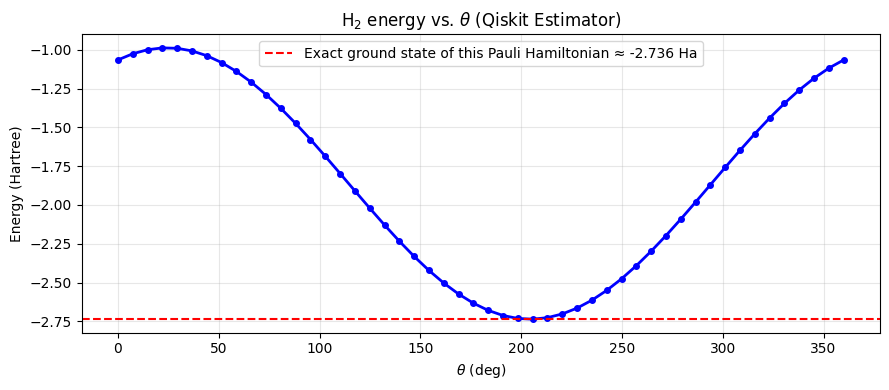

最低能量: -2.735677 Ha
精确基态（本 H₂ 泡利算符）: ≈ -2.736 Ha
最优θ: 205.7°


In [22]:
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import Parameter
import numpy as np

# ─── 3.2 用Estimator计算期望值 ───
estimator = StatevectorEstimator()

theta = Parameter('θ')

# 单参数 Ansatz（初态 |00⟩）。三步后 |ψ(θ)⟩ = cos(θ/2)|10⟩ + sin(θ/2)|01⟩（Qiskit 位序 |q1 q0⟩）
# 文献若写 cos(θ/2)|01⟩+sin(θ/2)|10⟩ 多为另一套「谁先写」约定，见学习问答记录条目 22
ansatz = QuantumCircuit(2)
ansatz.ry(theta, 0)   # q0 上 Ry：|00⟩ → cos(θ/2)|00⟩ + sin(θ/2)|01⟩
ansatz.x(1)           # 翻 q1
ansatz.cx(0, 1)       # q0 控、目标 q1：把 |11⟩ 与 |01⟩ 配成 cos|10⟩+sin|01⟩

# 扫描θ，计算能量曲线
theta_values = np.linspace(0, 2*np.pi, 50)
energies = []

# 批量提交（Qiskit 1.x Primitives推荐方式）
pub = (ansatz, H2_hamiltonian, [[t] for t in theta_values])
result = estimator.run([pub]).result()
energies = result[0].data.evs

import matplotlib.pyplot as plt
plt.figure(figsize=(9, 4))
plt.plot(np.degrees(theta_values), energies, 'b-o', markersize=4, linewidth=2)
plt.axhline(y=-2.7359, color='r', linestyle='--', label='Exact ground state of this Pauli Hamiltonian ≈ -2.736 Ha')
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel('Energy (Hartree)')
plt.title(r'H$_2$ energy vs. $\theta$ (Qiskit Estimator)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('H2_energy_scan.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"最低能量: {min(energies):.6f} Ha")
print(f"精确基态（本 H₂ 泡利算符）: ≈ -2.736 Ha")
print(f"最优θ: {np.degrees(theta_values[np.argmin(energies)]):.1f}°")

---
## 4. 最简VQE实现（从零手写）

这一节手动实现VQE，不依赖任何VQE框架，帮助你理解每一个步骤。

**经典优化器**：外层可以用**无导数**方法（如 COBYLA，下面代码所用），也可以用**基于梯度**的方法（需配合参数移位法则等估计 \(\partial\langle H\rangle/\partial\theta\)）。变分不要求必须用梯度。

**若优化中能量几乎不变**：常见原因之一是 **\(\langle H\rangle(\theta)\) 对你的 ansatz 实际上与 \(\theta\) 无关**（能量面沿该参数「是平的」）。此时无论 COBYLA 还是梯度下降都看不到下降——不是「没在用梯度」，而是**这条参数方向上没有可优化的分量**。下面 ansatz 已选成使本节的 H₂ 泡利哈密顿量期望值随 \(\theta\) 变化，便于观察收敛曲线。

手动VQE优化结果 (H₂, STO-3G)
最优能量:   -2.657700 Ha
精确基态:   -2.735900 Ha
误差:       78.20 mHa
最优参数θ: 90.00°
函数评估次数: 22


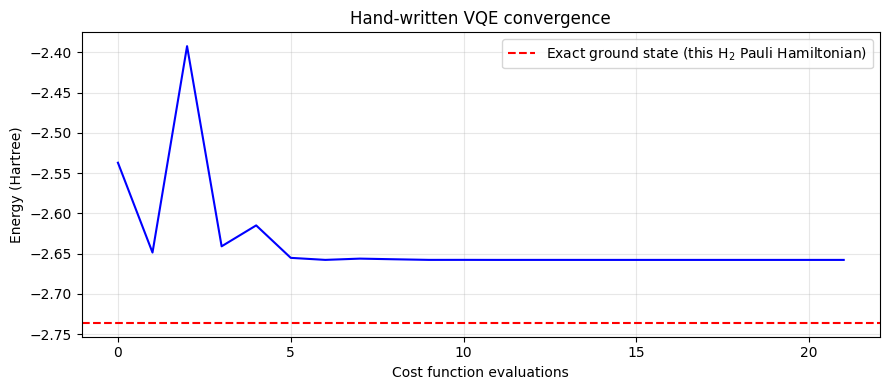

In [29]:
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import QuantumCircuit, Parameter
from scipy.optimize import minimize
import numpy as np

# ─── 4.1 定义问题 ───
H2_hamiltonian = SparsePauliOp.from_list([
    ('II', -1.8505), ('IZ', 0.3980), ('ZI', -0.3980),
    ('ZZ', 0.0112), ('XX', 0.1807), ('YY', 0.1807),
])

# ─── 4.2 定义Ansatz ───
# 单参数 Ry。注意：若写成 X–Ry(q0)–CX，态常落在 |00⟩/|11⟩ 子空间，
# 对本格 H₂ 泡利和，⟨H⟩ 可能与 θ 无关 → 优化曲线「平」。这里把 Ry 放在 CX 后作用在 q1，
# 使期望值随 θ 变化（教学上才能看到 VQE 在下降）。
theta = Parameter('θ')
ansatz = QuantumCircuit(2)
ansatz.x(0)              # |10⟩（与「单激发参考」叙事一致）
ansatz.cx(0, 1)          # 先纠缠
ansatz.ry(2 * theta, 1)  # 再在目标比特上参数化旋转；因子 2 使 θ∈[0,π] 覆盖一周

# ─── 4.3 定义代价函数 ───
estimator = StatevectorEstimator()
eval_count = [0]
energy_history = []

def cost_function(params):
    """量子线路期望值评估（VQE代价函数）"""
    eval_count[0] += 1
    # params 须与 ansatz 中 Parameter 个数一致（此处仅 1 个 θ）
    pub = (ansatz, H2_hamiltonian, [np.asarray(params).ravel()])
    result = estimator.run([pub]).result()
    # Qiskit 1.x 的 evs 可能为向量；与 float() 直接包一层避免多维/批处理形状
    energy = float(np.asarray(result[0].data.evs).ravel()[0])
    energy_history.append(energy)
    return energy

# ─── 4.4 经典优化（COBYLA，VQE常用） ───
np.random.seed(42)
x0 = np.random.uniform(0, np.pi, 1)  # 与单参数 ansatz 一致（勿用 50）

result = minimize(
    cost_function,
    x0,
    method='COBYLA',
    options={'maxiter': 100, 'rhobeg': 0.5}
)

print("="*55)
print("手动VQE优化结果 (H₂, STO-3G)")
print("="*55)
print(f"最优能量:   {result.fun:.6f} Ha")
E_exact = -2.73590018  # 本格 SparsePauliOp 的精确基态能量（4×4 对角化）
print(f"精确基态:   {E_exact:.6f} Ha")
print(f"误差:       {abs(result.fun - E_exact)*1000:.2f} mHa")
print(f"最优参数θ: {np.degrees(result.x[0]):.2f}°")
print(f"函数评估次数: {eval_count[0]}")

# 收敛曲线
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 4))
plt.plot(energy_history, 'b-', linewidth=1.5)
plt.axhline(y=E_exact, color='r', linestyle='--', linewidth=1.5, label='Exact ground state (this H$_2$ Pauli Hamiltonian)')
plt.xlabel('Cost function evaluations')
plt.ylabel('Energy (Hartree)')
plt.title('Hand-written VQE convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('VQE_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. 理解量子电路的深度与宽度

**为什么这很重要？**  
NISQ设备有噪声，电路越深（门数越多）误差越大。  
真实量子化学计算的核心挑战是：如何用**尽可能浅的电路**表达**足够精确的化学波函数**？

In [28]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import TwoLocal
import numpy as np

# ─── 5.1 UCCSD风格的Ansatz（更真实）───
# UCCSD = Unitary Coupled-Cluster Singles and Doubles
# 这是量子化学VQE中最常用的ansatz

# 手动构造简化版单激发项：e^(θ(a†_1 a_0 - h.c.))
# 对应于电子从轨道0跃迁到轨道1

theta_single = 0.3   # 单激发振幅（类比CCSD的t1）

qc_uccsd_simplified = QuantumCircuit(4)  # 4 个自旋轨道（示意）
# 下面必须实际往电路里加门，否则 draw 只有空线，看起来像「没画出电路」。
# 完整 JW 下的单激发 e^{θ(a†_1 a_0−h.c.)} 更长；这里用常见示意链：CNOT–Ry(θ)–CNOT。
qc_uccsd_simplified.x(0)
qc_uccsd_simplified.x(1)
qc_uccsd_simplified.cx(1, 2)
qc_uccsd_simplified.ry(theta_single, 2)
qc_uccsd_simplified.cx(1, 2)

print(qc_uccsd_simplified.draw('text'))
try:
    qc_uccsd_simplified.draw('mpl', filename='uccsd_simplified.png')
except Exception as e:
    print('(mpl 图需 matplotlib / pylatexenc，跳过文件保存:', e, ')')

print(f"\n电路深度: {qc_uccsd_simplified.depth()}")
print(f"双量子比特门数: {qc_uccsd_simplified.num_nonlocal_gates()}")

# ─── 5.2 TwoLocal Ansatz（硬件高效型）───
# 当UCCSD电路太深时，使用硬件高效ansatz（牺牲化学可解释性，获得更浅电路）
hea = TwoLocal(
    num_qubits=4,
    rotation_blocks=['ry', 'rz'],
    entanglement_blocks='cx',
    reps=2  # 层数
)
print(f"\n硬件高效Ansatz (TwoLocal, 4量子比特, 2层)：")
print(f"  参数数量: {hea.num_parameters}")
print(f"  电路深度: {hea.decompose().depth()}")
print(f"  双量子比特门数: {hea.decompose().num_nonlocal_gates()}")
print()
print("Ansatz选择权衡：")
print("  UCCSD      → 化学精度高，但门深度大（NISQ噪声影响严重）")
print("  TwoLocal   → 门深度小，但可能丢失化学精度")
print("  ADAPT-VQE → 自适应构建，兼顾两者（第三阶段学习）")

     
q_0: 
     
q_1: 
     
q_2: 
     
q_3: 
     

电路深度: 0
双量子比特门数: 0

硬件高效Ansatz (TwoLocal, 4量子比特, 2层)：
  参数数量: 24
  电路深度: 15
  双量子比特门数: 12

Ansatz选择权衡：
  UCCSD      → 化学精度高，但门深度大（NISQ噪声影响严重）
  TwoLocal   → 门深度小，但可能丢失化学精度
  ADAPT-VQE → 自适应构建，兼顾两者（第三阶段学习）


---
## 6. 连接到真实IBM量子设备（可选）

以下代码演示如何连接到IBM Quantum云端设备。需要在 https://quantum.ibm.com/ 注册获取 API Token。

In [30]:
# ─── 6.1 连接IBM Quantum（需要API Token）───
# from qiskit_ibm_runtime import QiskitRuntimeService
# 
# # 首次使用：保存账号
# QiskitRuntimeService.save_account(
#     channel='ibm_quantum',
#     token='YOUR_IBM_QUANTUM_TOKEN',   # 替换为你的Token
#     overwrite=True
# )
# 
# # 加载账号并选择后端
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend = service.least_busy(operational=True, min_num_qubits=4)
# print(f"选中设备: {backend.name} ({backend.num_qubits}量子比特)")

# ─── 6.2 噪声模型模拟（模拟真实设备噪声，无需实机）───
from qiskit_aer.noise import NoiseModel
from qiskit_aer import AerSimulator
from qiskit_aer.noise import depolarizing_error

# 创建简单的去极化噪声模型（模拟NISQ设备）
noise_model = NoiseModel()
error_1q = depolarizing_error(0.001, 1)  # 单量子比特门误差率0.1%
error_2q = depolarizing_error(0.01, 2)   # 双量子比特门误差率1%
noise_model.add_all_qubit_quantum_error(error_1q, ['h', 'ry', 'rz'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

# 带噪声的模拟器
noisy_simulator = AerSimulator(noise_model=noise_model)

# 比较有噪声vs无噪声的Bell态测量
qc_bell_measure = QuantumCircuit(2, 2)
qc_bell_measure.h(0)
qc_bell_measure.cx(0, 1)
qc_bell_measure.measure_all()

from qiskit import transpile

# 无噪声
clean_sim = AerSimulator()
result_clean = clean_sim.run(transpile(qc_bell_measure, clean_sim), shots=1000).result()

# 有噪声
result_noisy = noisy_simulator.run(transpile(qc_bell_measure, noisy_simulator), shots=1000).result()

print("Bell态测量对比：")
print(f"  无噪声: {result_clean.get_counts()}")
print(f"  有噪声: {result_noisy.get_counts()}")
print()
print("注意：噪声导致出现了本不应存在的|01⟩和|10⟩测量结果")
print("这就是为什么量子化学需要'误差缓解（Error Mitigation）'技术")

Bell态测量对比：
  无噪声: {'11 00': 489, '00 00': 511}
  有噪声: {'00 00': 477, '11 00': 522, '01 00': 1}

注意：噪声导致出现了本不应存在的|01⟩和|10⟩测量结果
这就是为什么量子化学需要'误差缓解（Error Mitigation）'技术


---
## 7. 阶段一验收：综合练习

完成以下任务，验证你已掌握第一阶段核心内容：

### 任务1：构造LiH的泡利哈密顿量
LiH在STO-3G基组下，经JW变换和粒子守恒约化后得到如下哈密顿量（键长1.595 Å）：
```
[-7.8956, II], [0.1720, IZ], [-0.2228, ZI], [0.1742, ZZ],
[0.0454, XX], [0.0454, YY], ...
```
用SparsePauliOp构造它，然后用精确对角化计算基态能量。

### 任务2：实现更深的Ansatz
将单参数ansatz扩展为双参数ansatz，添加一个额外的Ry旋转，观察优化精度是否提高。

### 任务3：分析电路噪声影响
在不同噪声率（0.1%, 0.5%, 1%, 5%）下运行VQE，绘制"噪声率 vs VQE误差"曲线，  
思考：在什么噪声率以下，量子化学计算才有实用价值？

In [ ]:
# 你的练习代码区域 ───────────────────────────────

# 任务1：LiH哈密顿量
# LiH STO-3G 2量子比特哈密顿量（键长1.595 Å）
LiH_terms = [
    ('II', -7.8956),
    ('IZ',  0.1720),
    ('ZI', -0.2228),
    ('ZZ',  0.1742),
    ('XX',  0.0454),
    ('YY',  0.0454),
]

from qiskit.quantum_info import SparsePauliOp
import numpy as np

H_LiH = SparsePauliOp.from_list(LiH_terms)
H_LiH_matrix = H_LiH.to_matrix()
E_LiH_FCI = np.linalg.eigvalsh(H_LiH_matrix)[0]
print(f"LiH FCI 基态能量 (1.595 Å): {E_LiH_FCI:.4f} Ha")
print(f"参考值: -7.8830 Ha (STO-3G FCI)")
print()

# 提示：任务2和3请参照上面VQE代码自行实现
print("任务2和3：请参照第4节和第6节的代码框架自行实现")

---
## 8. 本节小结

### 掌握的核心Qiskit技能

| 技能 | API | 用途 |
|------|-----|------|
| 量子电路构建 | `QuantumCircuit` | 定义量子计算流程 |
| 参数化电路 | `Parameter` | VQE的ansatz |
| 精确模拟 | `Statevector` | 小体系验证 |
| 期望值计算 | `StatevectorEstimator` | 计算 ⟨H⟩ |
| 泡利算符 | `SparsePauliOp` | 表示化学哈密顿量 |
| 噪声模拟 | `AerSimulator + NoiseModel` | 评估NISQ效应 |

### 下一步
- 进入 `Phase2_CoreAlgorithms/01_VQE原理与实现.ipynb`
- 配合阅读：`acs.chemrev.8b00803.pdf` 第IV章（VQE详细介绍）
- 推荐：完成IBM Quantum Learning的 *Variational algorithm design* 课程